IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'figure.facecolor': 'white'})

IMPORT DATASET

In [2]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, parse_dates=['Date'])
print(f'Loaded: {len(df):,} rows, {len(df.columns)} columns')
print(f'Period: {df["Date"].min().date()} to {df["Date"].max().date()}')

Saving groundwater_urban_abstraction.csv to groundwater_urban_abstraction.csv
Loaded: 7,300 rows, 17 columns
Period: 2005-01-01 to 2024-12-26


INSPECT DATASET

In [3]:
print(df.head(10))
print('\n')
df.info()
print('\n')
print(df.describe().round(2).to_string())
print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'There are no missing values.')

        Date  GWL_mbgl  Pumping_Rate_MLd  Rainfall_mm  Temperature_C  \
0 2005-01-01      6.13              21.2          0.5            5.4   
1 2005-01-02      6.25              32.7          0.3            3.0   
2 2005-01-03      5.96              25.0          6.8            1.7   
3 2005-01-04      6.11              25.0          7.1            0.1   
4 2005-01-05      6.18              25.0          2.9            2.9   
5 2005-01-06      6.16              25.0          1.8            4.1   
6 2005-01-07      5.95              25.0          5.0            2.5   
7 2005-01-08      5.86              21.3          3.1            1.9   
8 2005-01-09      6.01              21.3          1.0            2.7   
9 2005-01-10      6.23              25.0          7.1            5.4   

   Effective_Recharge_mm  EC_uScm  Nitrate_mgL  Year  Month  DayOfYear  \
0                   0.09    486.0         19.2  2005      1          1   
1                   0.05    443.0         21.6  2005      1

TIME SERIES OVERVIEW PLOT

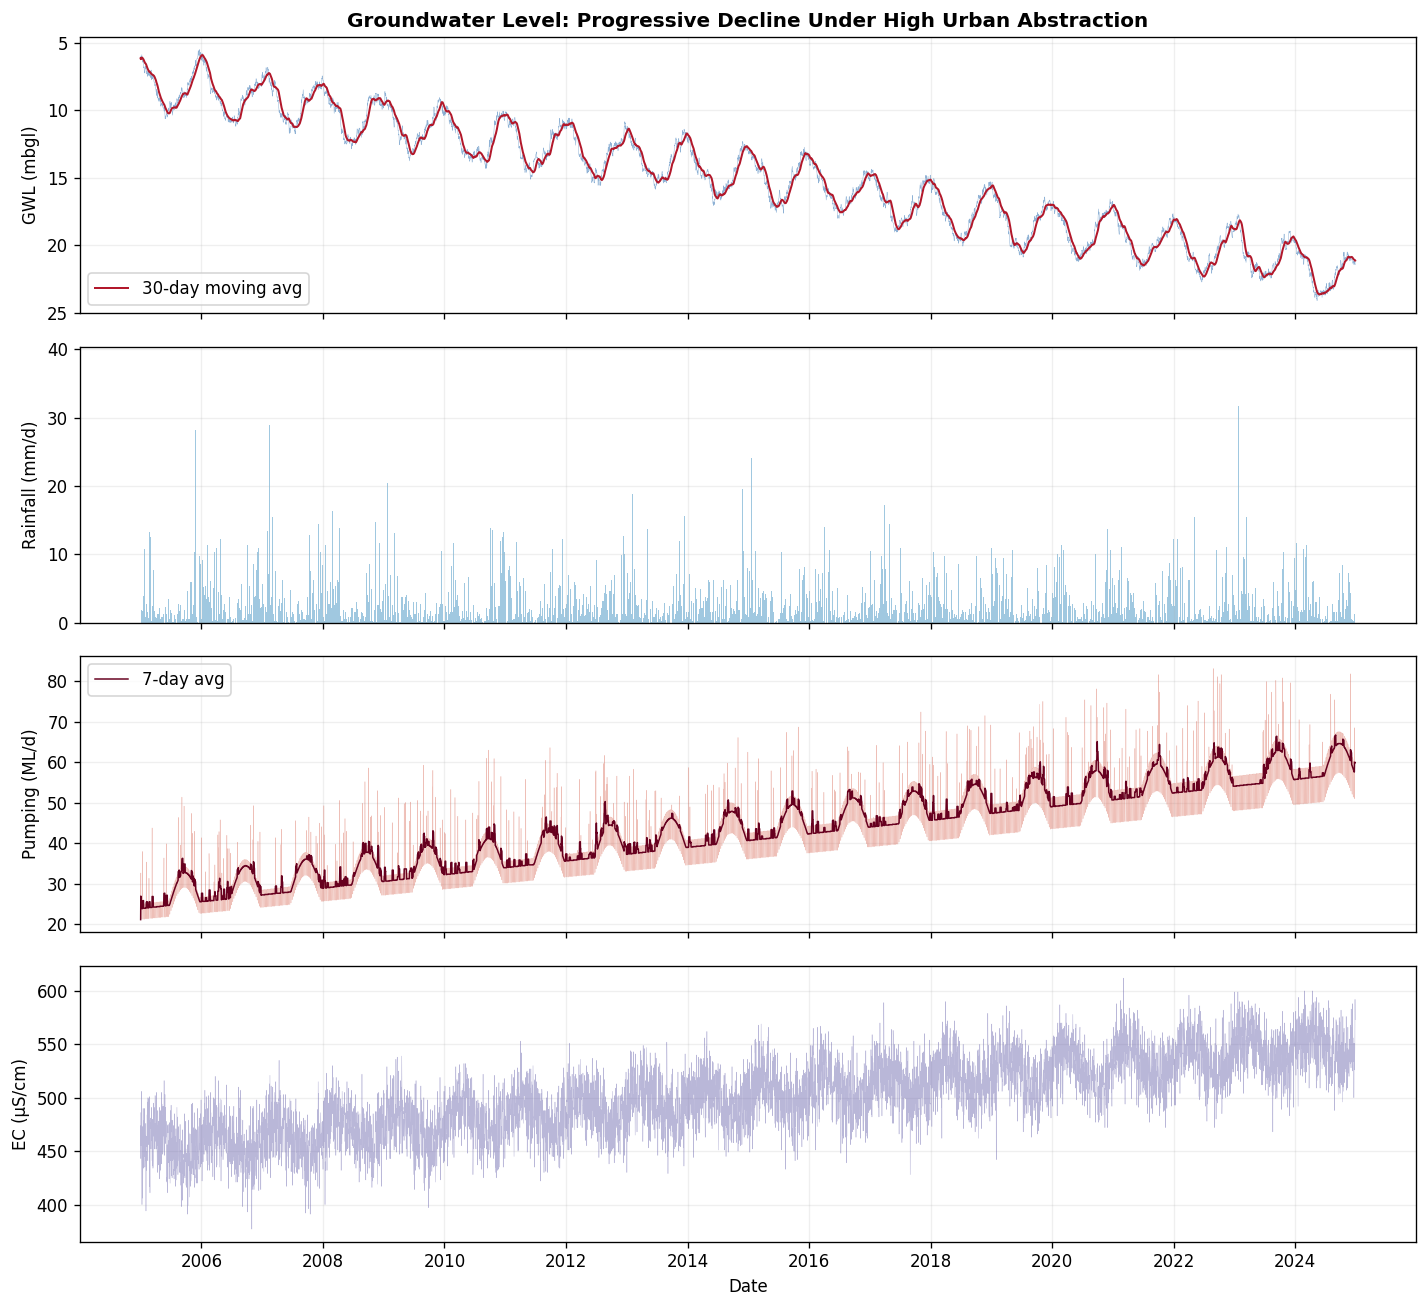

In [4]:
fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

ax[0].plot(df['Date'], df['GWL_mbgl'], lw=0.3, color='#2166ac', alpha=0.5)
ax[0].plot(df['Date'], df['GWL_30d_avg'], lw=1.2, color='#b2182b', label='30-day moving avg')
ax[0].set_ylabel('GWL (mbgl)')
ax[0].set_title('Groundwater Level: Progressive Decline Under High Urban Abstraction',
                   fontsize=12, fontweight='bold')
ax[0].invert_yaxis()
ax[0].legend(loc='lower left')

ax[1].bar(df['Date'], df['Rainfall_mm'], width=1, color='#4393c3', alpha=0.5)
ax[1].set_ylabel('Rainfall (mm/d)')

ax[2].plot(df['Date'], df['Pumping_Rate_MLd'], lw=0.3, color='#d6604d', alpha=0.4)
ax[2].plot(df['Date'], df['Pumping_7d_avg'], lw=0.9, color='#67001f', label='7-day avg')
ax[2].set_ylabel('Pumping (ML/d)')
ax[2].legend(loc='upper left')

ax[3].plot(df['Date'], df['EC_uScm'], lw=0.3, color='#7570b3', alpha=0.5)
ax[3].set_ylabel('EC (µS/cm)')
ax[3].set_xlabel('Date')

for a in ax:
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    a.grid(alpha=0.2)

plt.tight_layout()
plt.show()

CORRELATION MATRIX

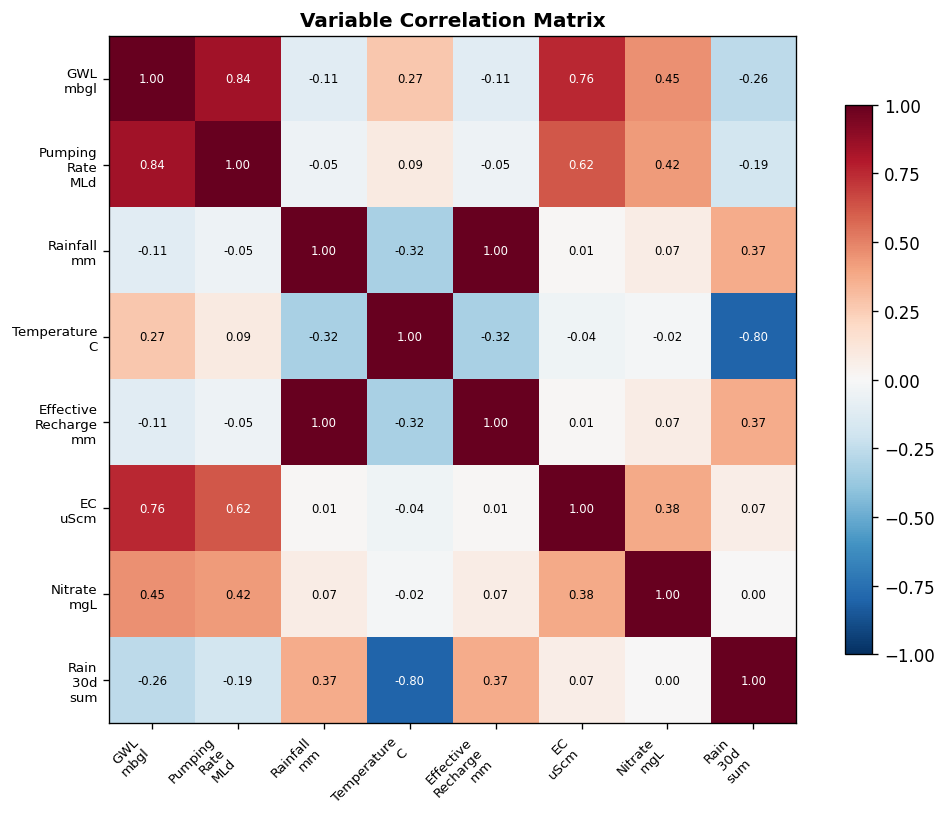


Correlations with GWL (sorted by strength):
  Pumping_Rate_MLd           r = +0.840
  EC_uScm                    r = +0.757
  Nitrate_mgL                r = +0.454
  Temperature_C              r = +0.272
  Rain_30d_sum               r = -0.264
  Rainfall_mm                r = -0.114
  Effective_Recharge_mm      r = -0.114


In [5]:
cols = ['GWL_mbgl','Pumping_Rate_MLd','Rainfall_mm','Temperature_C',
                'Effective_Recharge_mm','EC_uScm','Nitrate_mgL','Rain_30d_sum']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
labels = [c.replace('_', '\n') for c in cols]
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(corr.values[i,j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Variable Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCorrelations with GWL (sorted by strength):')
gwl_corr = corr['GWL_mbgl'].drop('GWL_mbgl').sort_values(key=abs, ascending=False)
for var, val in gwl_corr.items():
    print(f'  {var:25s}  r = {val:+.3f}')

SEASONAL AND ANNUAL PATTERNS

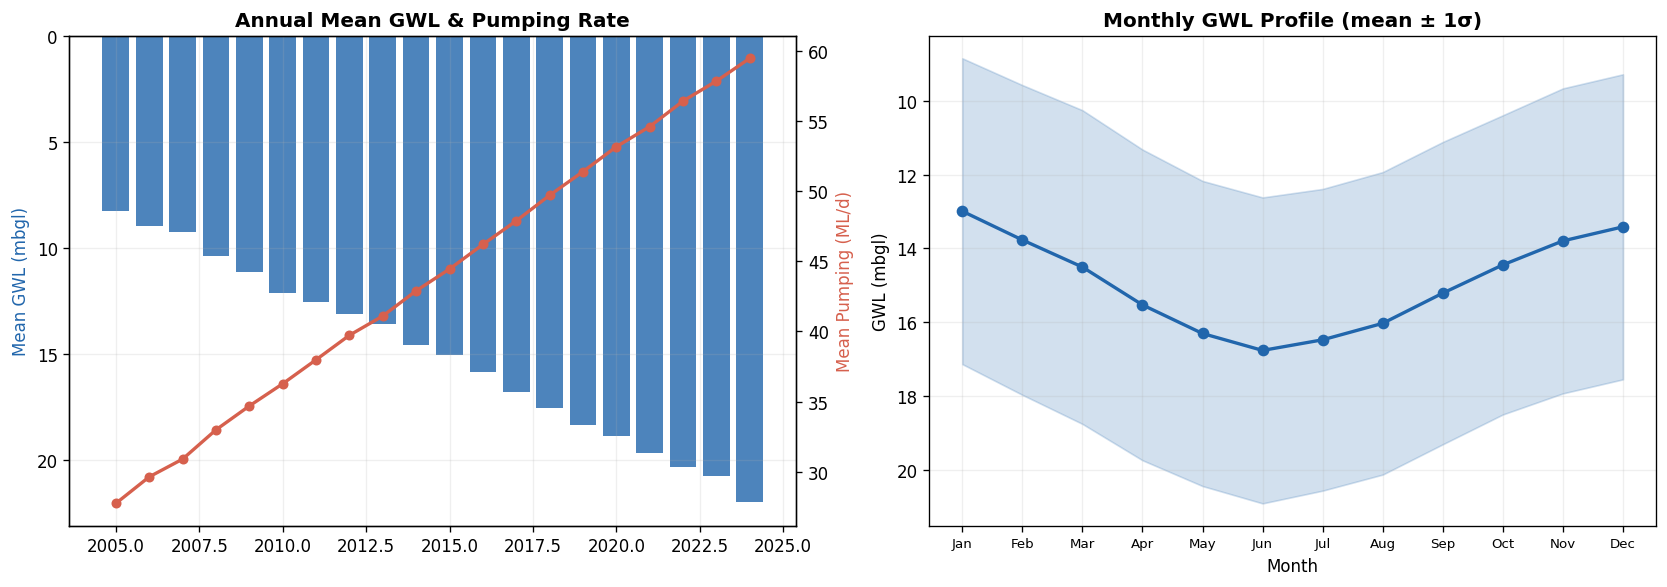

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

annual = df.groupby('Year').agg({'GWL_mbgl':'mean','Pumping_Rate_MLd':'mean'}).reset_index()
ax1 = ax[0]
ax1.bar(annual['Year'], annual['GWL_mbgl'], color='#2166ac', alpha=0.8)
ax1.set_ylabel('Mean GWL (mbgl)', color='#2166ac')
ax1.set_title('Annual Mean GWL & Pumping Rate', fontweight='bold')
ax1.invert_yaxis()
ax2 = ax1.twinx()
ax2.plot(annual['Year'], annual['Pumping_Rate_MLd'], 'o-', color='#d6604d', markersize=5, lw=2)
ax2.set_ylabel('Mean Pumping (ML/d)', color='#d6604d')

monthly = df.groupby('Month')['GWL_mbgl'].agg(['mean','std']).reset_index()
ax[1].fill_between(monthly['Month'], monthly['mean']-monthly['std'],
                      monthly['mean']+monthly['std'], alpha=0.2, color='#2166ac')
ax[1].plot(monthly['Month'], monthly['mean'], 'o-', color='#2166ac', markersize=6, lw=2)
ax[1].set_xlabel('Month')
ax[1].set_ylabel('GWL (mbgl)')
ax[1].set_title('Monthly GWL Profile (mean ± 1σ)', fontweight='bold')
ax[1].set_xticks(range(1,13))
ax[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax[1].invert_yaxis()

for a in ax:
    a.grid(alpha=0.2)
plt.tight_layout()
plt.show()

SCATTER PLOT SHOWING PUMPING VS GROUNDWATER LEVEL BY PERIOD

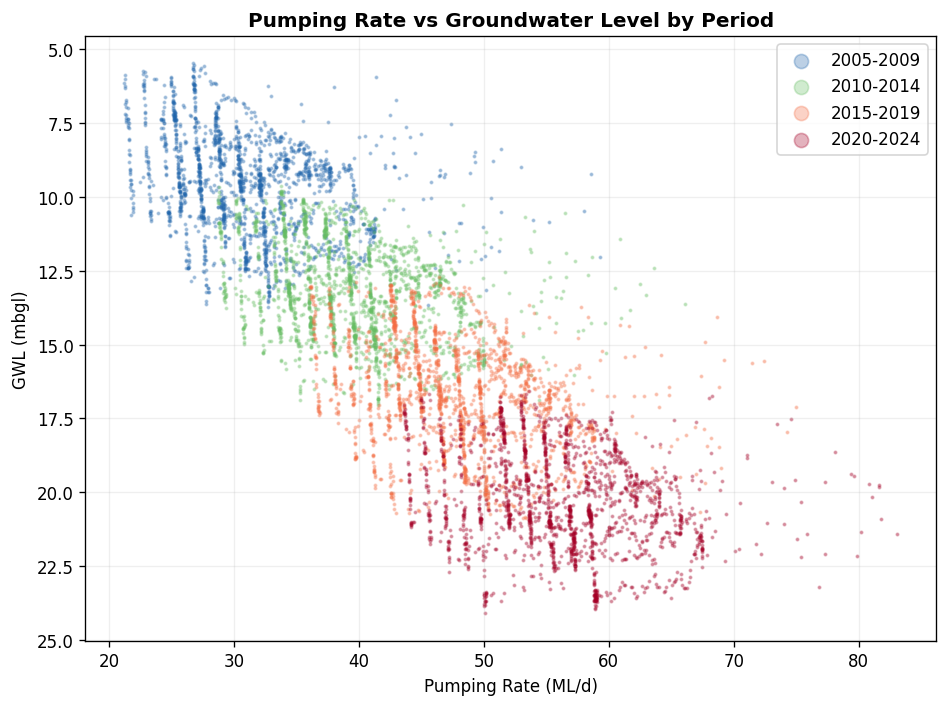

In [7]:
df['Decade'] = np.where(df['Year'] < 2010, '2005-2009',
               np.where(df['Year'] < 2015, '2010-2014',
               np.where(df['Year'] < 2020, '2015-2019', '2020-2024')))

fig, ax = plt.subplots(figsize=(8, 6))
colours = {'2005-2009': '#2166ac', '2010-2014': '#66bd63', '2015-2019': '#f46d43', '2020-2024': '#a50026'}
for period, colour in colours.items():
    mask = df['Decade'] == period
    ax.scatter(df.loc[mask, 'Pumping_Rate_MLd'], df.loc[mask, 'GWL_mbgl'],
               s=2, alpha=0.3, c=colour, label=period)
ax.set_xlabel('Pumping Rate (ML/d)')
ax.set_ylabel('GWL (mbgl)')
ax.set_title('Pumping Rate vs Groundwater Level by Period', fontweight='bold')
ax.invert_yaxis()
ax.legend(markerscale=6)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

FEATURE ENGINEERING

In [8]:
df['Time_Index'] = (df['Date'] - df['Date'].min()).dt.days
df['GWL_lag7']  = df['GWL_mbgl'].shift(7)
df['GWL_lag30'] = df['GWL_mbgl'].shift(30)
df['Pumping_lag1']   = df['Pumping_Rate_MLd'].shift(1)
df['Rain_lag7_sum']  = df['Rainfall_mm'].rolling(7, min_periods=1).sum()
df['Pumping_x_Temp'] = df['Pumping_Rate_MLd'] * df['Temperature_C']
df['Cum_Deficit']    = (df['Pumping_Rate_MLd'] * 0.01 - df['Effective_Recharge_mm']).cumsum()

model_df = df.dropna().copy()
print(f'Model ready rows: {len(model_df):,} (dropped {len(df) - len(model_df)} from lag creation)')
print(f'Total features available: {len(model_df.columns)}')

Model ready rows: 7,270 (dropped 30 from lag creation)
Total features available: 25


SPLIT DATASET

In [9]:
features = [
    'Pumping_Rate_MLd', 'Rainfall_mm', 'Temperature_C','Effective_Recharge_mm', 'EC_uScm', 'Nitrate_mgL',
    'Month', 'DayOfYear', 'Weekday','Pumping_7d_avg', 'Rain_30d_sum','GWL_lag7', 'GWL_lag30',
    'Pumping_lag1', 'Rain_lag7_sum', 'Pumping_x_Temp', 'Cum_Deficit', 'Time_Index'
]

target = 'GWL_mbgl'

X = model_df[features].values
y = model_df[target].values

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = model_df['Date'].values[split_idx:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Features:     {len(features)}')

# Instatiate Models

models = {
    'Linear Regression': LinearRegression(),
    'Lasso (a=0.01)': Lasso(alpha=0.01, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42),
}

results = {}
predictions = {}

# Print Model Results
print('\nModel Results:')
print('-' * 70)
for name, model in models.items():
    use_scaled = 'Linear' in name or 'Lasso' in name
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = y_pred

    print(f'{name:25s}  MAE={mae:.4f}m   RMSE={rmse:.4f}m   R2={r2:.5f}')

Training set: 5,816 samples
Test set:     1,454 samples
Features:     18

Model Results:
----------------------------------------------------------------------
Linear Regression          MAE=0.2892m   RMSE=0.3603m   R2=0.94228
Lasso (a=0.01)             MAE=0.2938m   RMSE=0.3673m   R2=0.94000
Random Forest              MAE=0.9020m   RMSE=1.1921m   R2=0.36791
Gradient Boosting          MAE=1.2679m   RMSE=1.5420m   R2=-0.05755


MODEL PREDICTIONS VS ACTUAL

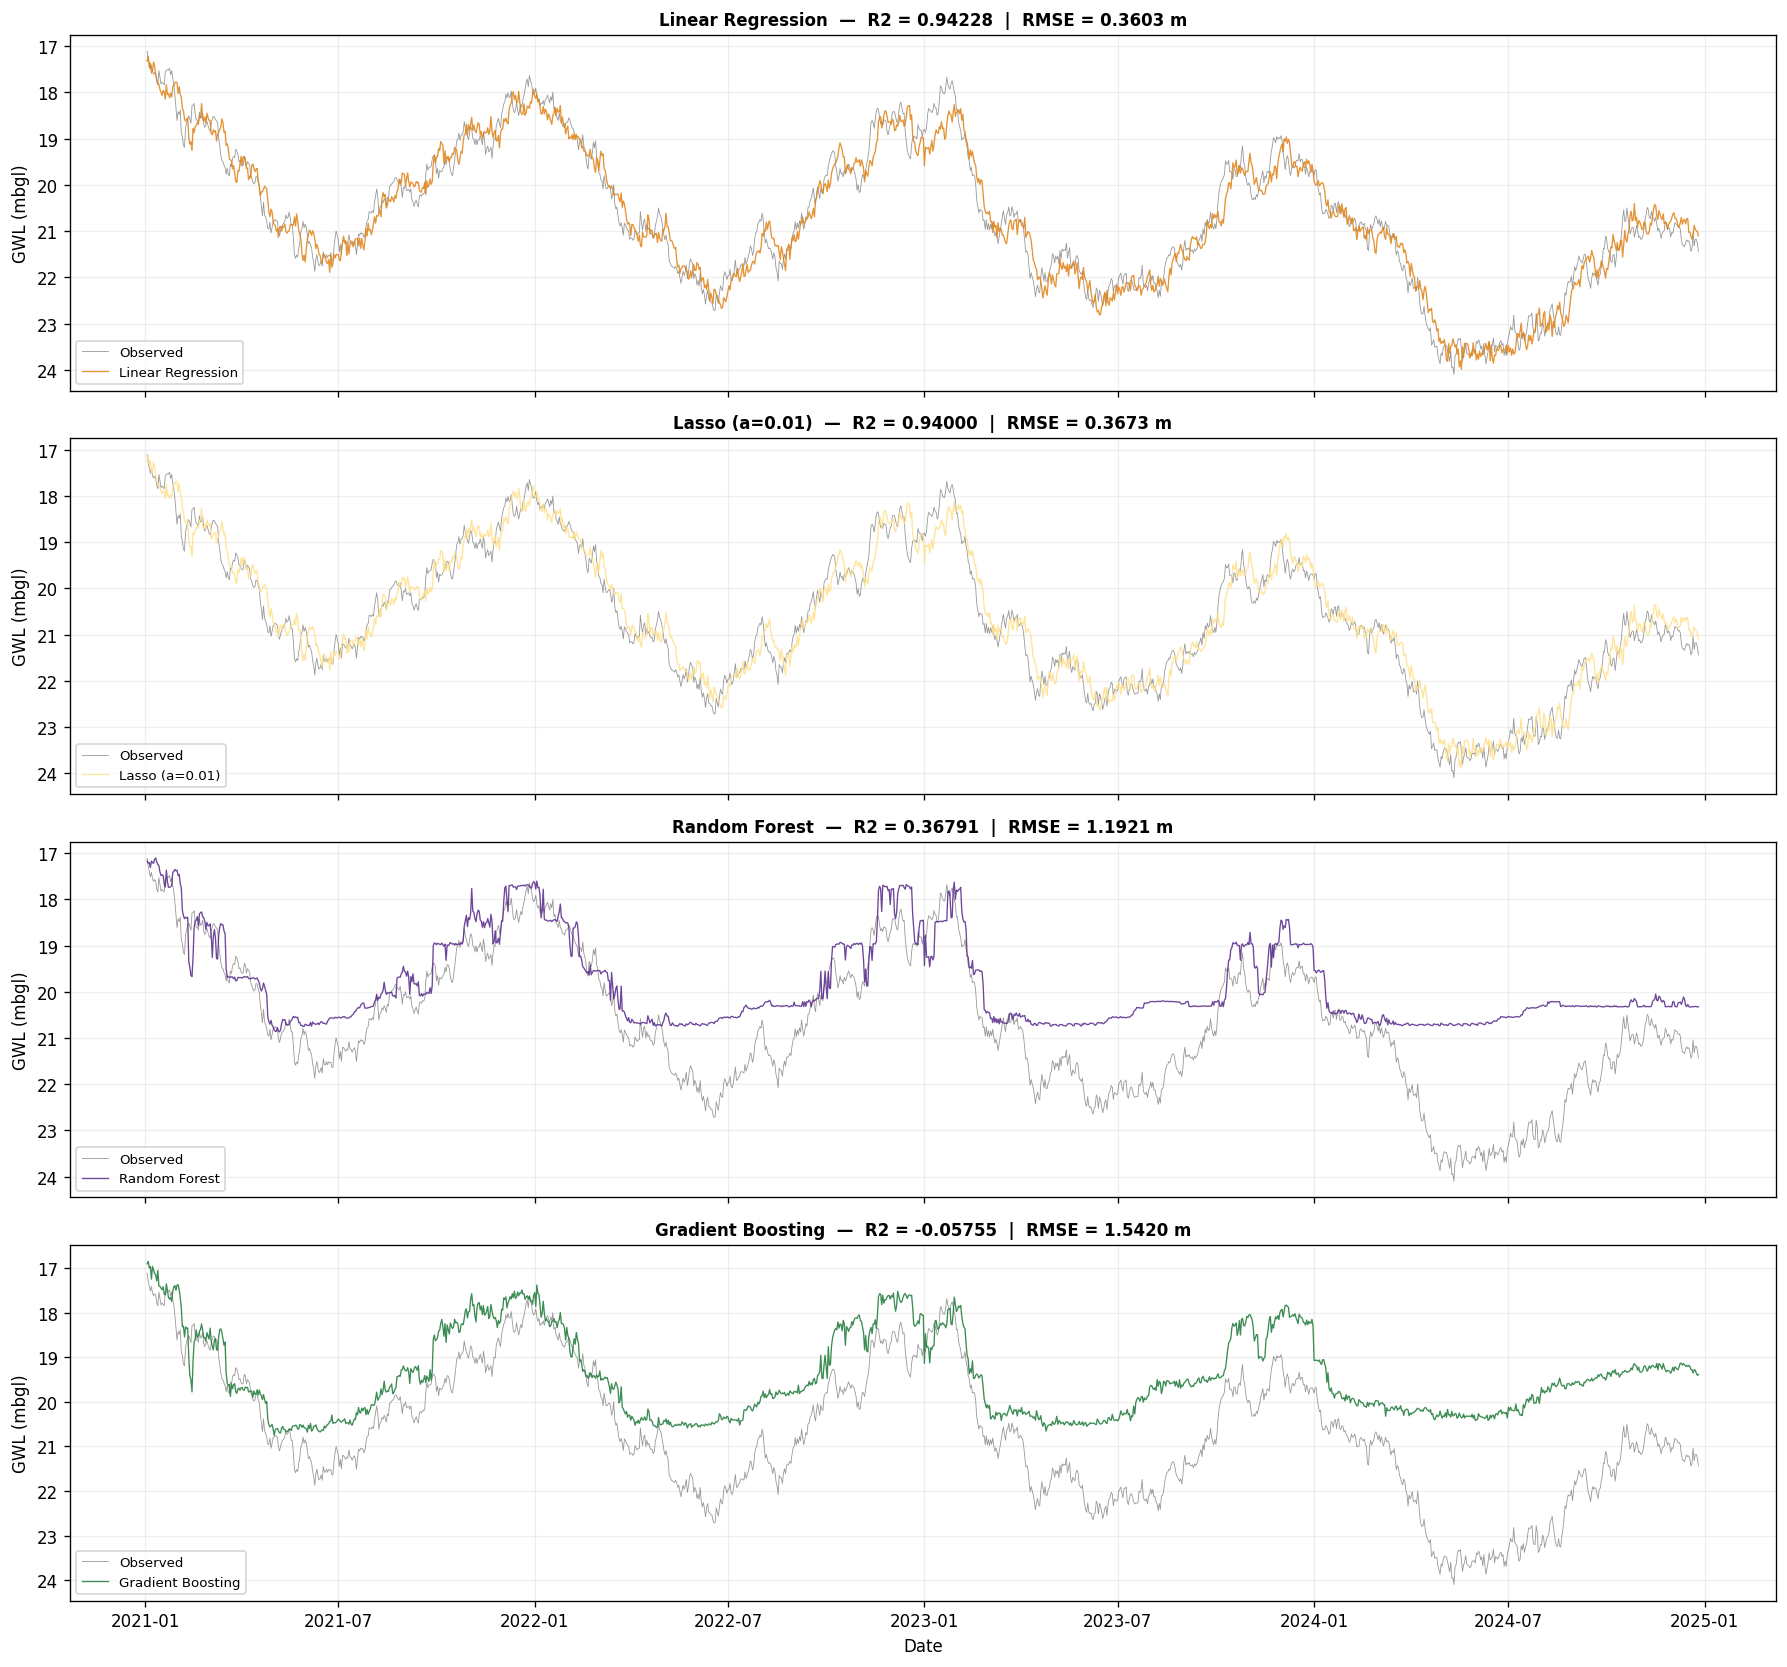

In [10]:
model_colours = {'Linear Regression': '#e08214','Lasso (a=0.01)':   '#fee08b',
                 'Random Forest': '#542788', 'Gradient Boosting': '#1b7837'}

fig, axes = plt.subplots(4, 1, figsize=(15, 3.5 * 4), sharex=True)

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.plot(dates_test, y_test, lw=0.5, color='#333', alpha=0.5, label='Observed')
    ax.plot(dates_test, y_pred, lw=0.8, color=model_colours[name], alpha=0.85, label=name)
    r2 = results[name]['R2']
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_ylabel('GWL (mbgl)')
    ax.set_title(f'{name}  —  R2 = {r2:.5f}  |  RMSE = {rmse:.4f} m',
                 fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE

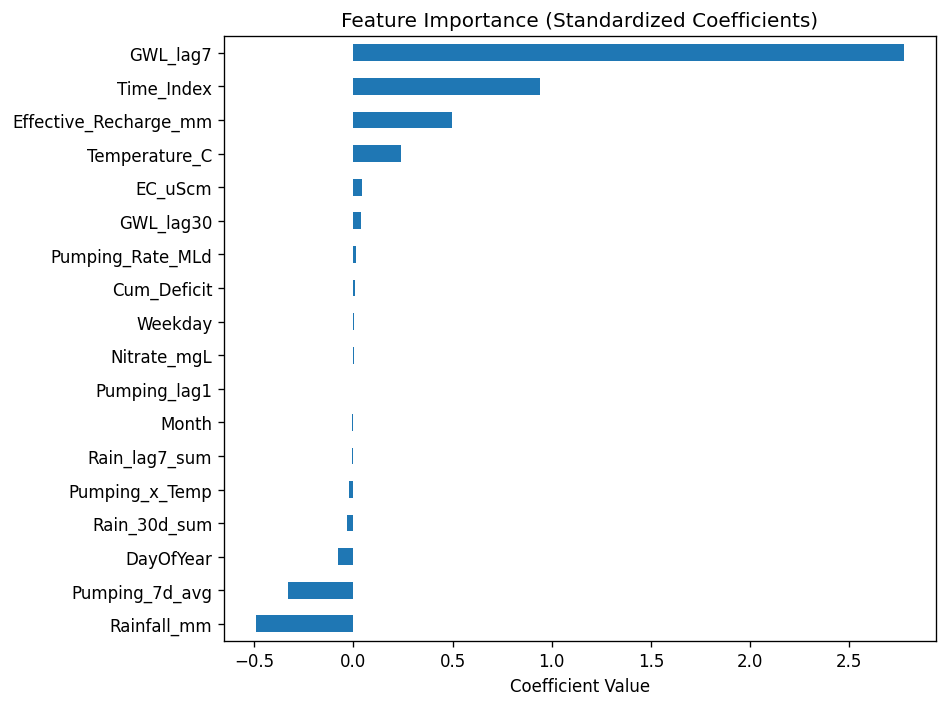

In [11]:
# Extract feature importance from the best Model

importance = pd.Series(models['Linear Regression'].coef_, index=features).sort_values(ascending=True)
importance.plot(figsize = (8, 6), kind='barh')
plt.title('Feature Importance (Standardized Coefficients)')
plt.xlabel('Coefficient Value')
plt.tight_layout()

CLASSIFICATION BASED ON EXTRACTION AND ENVIRONMENTAL CONDITIONS.

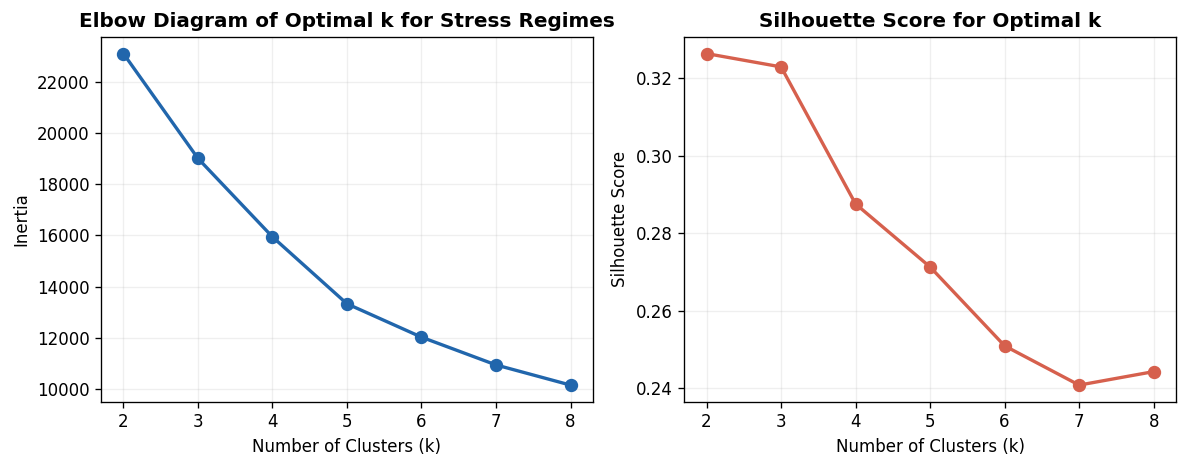

In [12]:
cluster_features = ['GWL_mbgl', 'Pumping_Rate_MLd', 'Rainfall_mm', 'EC_uScm', 'Temperature_C']
X_clust = df[cluster_features].values
X_clust_s = StandardScaler().fit_transform(X_clust)

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_s)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_clust_s, labels))  # added

fig, ax = plt.subplots(1,2,figsize=(10,4))

# --- Plot 1: Elbow ---
ax[0].plot(K_range, inertias, 'o-', color='#2166ac', lw=2, markersize=7)
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Diagram of Optimal k for Stress Regimes', fontweight='bold')

# --- Plot 2: Silhouette Score ---
ax[1].plot(K_range, silhouette_scores, 'o-', color='#d6604d', lw=2, markersize=7)
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score for Optimal k', fontweight='bold')

for a in ax:
  a.grid(alpha = 0.2)

plt.tight_layout()

VISUALIZE AQUIFER STRESS REGIMES

Cluster profiles (mean values):
                 GWL_mbgl  Pumping_Rate_MLd  Rainfall_mm  EC_uScm  Temperature_C
Stress_Regime                                                                   
High Stress         18.78             52.84         1.97   527.79          11.95
Low Stress          11.51             35.30         1.83   473.63          11.23
Moderate Stress     13.04             40.51        10.54   497.83           5.87


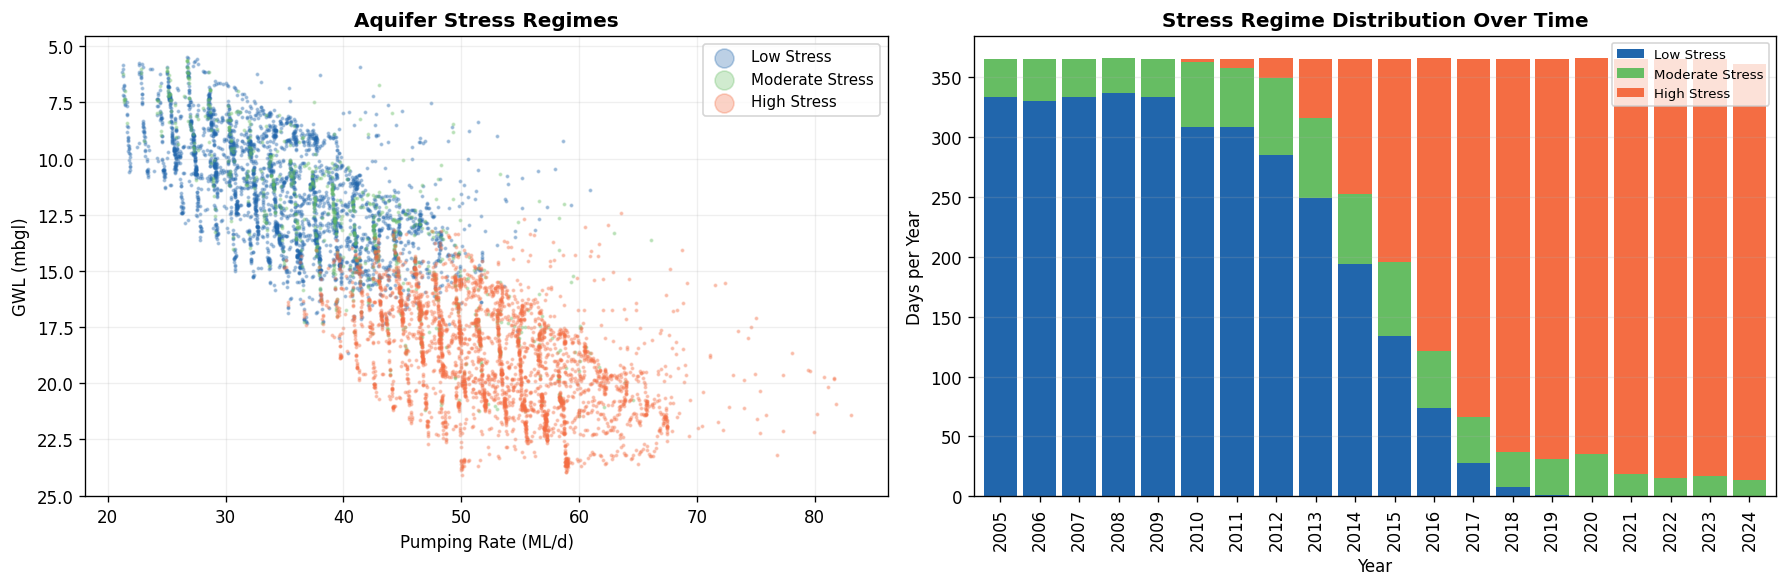

In [13]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_clust_s)

cluster_means = df.groupby('Cluster')['GWL_mbgl'].mean().sort_values()
stress_labels = ['Low Stress', 'Moderate Stress', 'High Stress']
label_map = {clust: stress_labels[i] for i, clust in enumerate(cluster_means.index)}
df['Stress_Regime'] = df['Cluster'].map(label_map)

print('Cluster profiles (mean values):')
print(df.groupby('Stress_Regime')[cluster_features].mean().round(2).to_string())

cmap = {'Low Stress': '#2166ac', 'Moderate Stress': '#66bd63','High Stress': '#f46d43'}

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax1 = ax[0]
for regime, colour in cmap.items():
    mask = df['Stress_Regime'] == regime
    ax1.scatter(df.loc[mask, 'Pumping_Rate_MLd'], df.loc[mask, 'GWL_mbgl'],
               s=2, alpha=0.3, c=colour, label=regime)
ax1.set_xlabel('Pumping Rate (ML/d)')
ax1.set_ylabel('GWL (mbgl)')
ax1.set_title('Aquifer Stress Regimes', fontweight='bold')
ax1.invert_yaxis()
ax1.legend(markerscale=8, fontsize=9)
ax1.grid(alpha=0.2)

ax2 = ax[1]
yearly_regime = df.groupby(['Year','Stress_Regime']).size().unstack(fill_value=0)
yearly_regime = yearly_regime[[c for c in stress_labels if c in yearly_regime.columns]]
yearly_regime.plot(kind='bar', stacked=True, ax=ax2,
                   color=[cmap[c] for c in yearly_regime.columns], width=0.85)
ax2.set_xlabel('Year')
ax2.set_ylabel('Days per Year')
ax2.set_title('Stress Regime Distribution Over Time', fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

PCA VISUALIZATION OF CLUSTERS

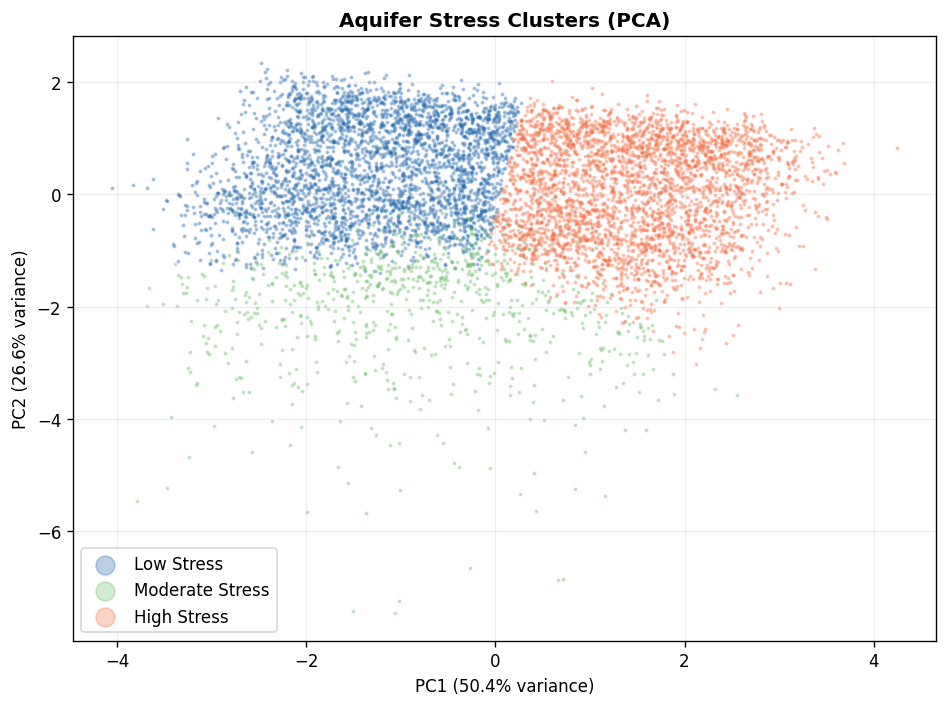

PCA loadings:
                    PC1    PC2
GWL_mbgl          0.609  0.021
Pumping_Rate_MLd  0.565 -0.093
Rainfall_mm      -0.094 -0.677
EC_uScm           0.529 -0.238
Temperature_C     0.148  0.690


In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_s)

fig, ax = plt.subplots(figsize=(8, 6))
for regime, colour in cmap.items():
    mask = df['Stress_Regime'] == regime
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=2, alpha=0.3, c=colour, label=regime)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Aquifer Stress Clusters (PCA)', fontweight='bold')
ax.legend(markerscale=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('PCA loadings:')
loadings = pd.DataFrame(pca.components_.T, index=cluster_features, columns=['PC1','PC2'])
print(loadings.round(3).to_string())

SUMMARY OF KEY FINDINGS

In [15]:
first_5 = df[df['Year'] <= 2009]
last_5 = df[df['Year'] >= 2020]

print('=' * 65)
print('  SUMMARY: GROUNDWATER UNDER HIGH URBAN ABSTRACTION')
print('=' * 65)
print(f'''
  AQUIFER DECLINE
    Mean GWL 2005-2009:   {first_5["GWL_mbgl"].mean():.1f} mbgl
    Mean GWL 2020-2024:   {last_5["GWL_mbgl"].mean():.1f} mbgl
    Total deepening:      {last_5["GWL_mbgl"].mean() - first_5["GWL_mbgl"].mean():.1f} m

  PUMPING ESCALATION
    Mean pumping 2005-2009: {first_5["Pumping_Rate_MLd"].mean():.1f} ML/d
    Mean pumping 2020-2024: {last_5["Pumping_Rate_MLd"].mean():.1f} ML/d

  WATER QUALITY DETERIORATION
    Mean EC 2005-2009:     {first_5["EC_uScm"].mean():.0f} uS/cm
    Mean EC 2020-2024:     {last_5["EC_uScm"].mean():.0f} uS/cm

  ML PERFORMANCE (best model)''')
best = max(results, key=lambda k: results[k]['R2'])
print(f'{best}: R2 = {results[best]["R2"]:.5f}, RMSE = {results[best]["RMSE"]:.4f} m')

high_early = len(first_5[first_5.get('Stress_Regime', '') == 'High Stress']) if 'Stress_Regime' in first_5.columns else 0
high_late = len(last_5[last_5.get('Stress_Regime', '') == 'High Stress']) if 'Stress_Regime' in last_5.columns else 0
print(f'''
  STRESS REGIME SHIFT
    High stress days 2005-2009: {high_early}
    High stress days 2020-2024: {high_late}
''')
print('=' * 65)

  SUMMARY: GROUNDWATER UNDER HIGH URBAN ABSTRACTION

  AQUIFER DECLINE
    Mean GWL 2005-2009:   9.6 mbgl
    Mean GWL 2020-2024:   20.3 mbgl
    Total deepening:      10.7 m

  PUMPING ESCALATION
    Mean pumping 2005-2009: 31.2 ML/d
    Mean pumping 2020-2024: 56.3 ML/d

  WATER QUALITY DETERIORATION
    Mean EC 2005-2009:     463 uS/cm
    Mean EC 2020-2024:     538 uS/cm

  ML PERFORMANCE (best model)
Linear Regression: R2 = 0.94228, RMSE = 0.3603 m

  STRESS REGIME SHIFT
    High stress days 2005-2009: 0
    High stress days 2020-2024: 1722

